<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 74 · Hypothesis Testing &amp; Inference</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">The Logic of Hypothesis Testing 🧪</div>
  <div style="font-size:15px;color:#eef2ff;max-width:740px;line-height:1.6">Every test answers one question: is the effect in the data real, or could chance alone explain it? We meet the four-step framework, hypotheses, a test statistic, its null distribution, a p-value and decision, then run our first real test on a factory short-fill claim.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
IND="#4f46e5"; DEEP="#4338ca"; LIGHT="#818cf8"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(74)

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 1 · THE TWO HYPOTHESES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">H0 the skeptic, H1 the claim</div>
<div style="color:#4a5578;margin-top:6px">Every test pits a null hypothesis H0 (nothing is going on, the default) against an alternative H1 (the effect the investigator suspects). We start skeptical and ask the data for evidence against H0. Example: a coin lands heads 62 times in 100 tosses, is it fair?</div>
</div>

In [2]:
heads, n = 62, 100
p0 = 0.5            # H0: the coin is fair
phat = heads/n
print(f"H0: p = {p0}  (fair coin)   vs   H1: p != {p0}  (biased)")
print(f"observed: {heads}/{n} heads = {phat:.0%}")
print("we do NOT yet conclude bias; we ask: how surprising is 62 heads if the coin is truly fair?")

H0: p = 0.5  (fair coin)   vs   H1: p != 0.5  (biased)
observed: 62/100 heads = 62%
we do NOT yet conclude bias; we ask: how surprising is 62 heads if the coin is truly fair?


We never "prove" H1. We see whether the data is too unlikely under H0 to keep believing it, exactly like a court that presumes innocence (H0) until the evidence is strong enough to reject that presumption.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 2 · THE NULL WORLD & THE TEST STATISTIC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Simulate the world where H0 is true</div>
<div style="color:#4a5578;margin-top:6px">A test statistic measures how far the data sits from H0, in standard-error units. To judge it, we build its sampling distribution UNDER H0, here by simulating thousands of fair-coin experiments, and see where our value falls.</div>
</div>

standard error under H0 = 0.0500
test statistic z = (phat - p0)/SE = 2.40  (about 2.4 SEs above 0.5)
in 100 fair tosses, simulated mean heads-fraction = 0.500 (centered on 0.50, as it must be)


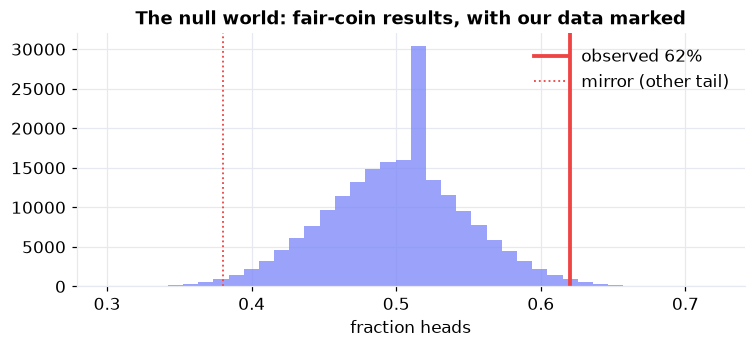

In [3]:
sim = rng.binomial(n, p0, 200_000) / n      # fair-coin worlds
se0 = np.sqrt(p0*(1-p0)/n)
z = (phat - p0)/se0
print(f"standard error under H0 = {se0:.4f}")
print(f"test statistic z = (phat - p0)/SE = {z:.2f}  (about {z:.1f} SEs above 0.5)")
print(f"in {n} fair tosses, simulated mean heads-fraction = {sim.mean():.3f} (centered on 0.50, as it must be)")
fig,ax=plt.subplots(figsize=(7,3.3))
ax.hist(sim, bins=40, color=LIGHT, alpha=0.8)
ax.axvline(phat, color=RED, lw=2.5, label=f"observed {phat:.0%}")
ax.axvline(1-phat, color=RED, lw=1.2, ls=":", label="mirror (other tail)")
ax.set_title("The null world: fair-coin results, with our data marked"); ax.set_xlabel("fraction heads"); ax.legend()
plt.tight_layout(); plt.show()

The histogram is what "no effect" looks like: fair coins cluster around 0.50. Our 62% sits out in the tail. The test statistic z says it is about <strong>2.4 standard errors</strong> from the null value, far enough to start doubting the coin.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4338ca;letter-spacing:1px">DEMO 3 · THE p-VALUE & THE DECISION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How surprising is the data if H0 is true?</div>
<div style="color:#4a5578;margin-top:6px">The p-value is the probability of a result at least as extreme as ours, computed UNDER H0. Small p means 'this would rarely happen by chance', evidence against H0. We compare p to a significance level alpha (commonly 0.05) and either reject or fail to reject H0.</div>
</div>

In [4]:
p_sim = np.mean(np.abs(sim - p0) >= abs(phat - p0))     # two-sided, by simulation
p_formula = 2*(1 - stats.norm.cdf(abs(z)))                # normal approximation
print(f"two-sided p-value (simulation) = {p_sim:.4f}")
print(f"two-sided p-value (formula)    = {p_formula:.4f}")
alpha = 0.05
print(f"\nalpha = {alpha}")
print("REJECT H0: the coin is very likely biased" if p_formula < alpha else "FAIL TO REJECT H0")
print("\nMeaning of p: IF the coin were fair, we would see a split this lopsided only about 1.6% of the time.")

two-sided p-value (simulation) = 0.0208
two-sided p-value (formula)    = 0.0164

alpha = 0.05
REJECT H0: the coin is very likely biased

Meaning of p: IF the coin were fair, we would see a split this lopsided only about 1.6% of the time.


A p-value is <em>not</em> the probability that H0 is true; it is the probability of data this extreme assuming H0 is true. Because p &#8776; 0.016 is below 0.05, we reject the fair-coin hypothesis. The four steps, state H0/H1, choose a statistic, find its null distribution, compute p and decide, are the skeleton of every test in this Part.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · SHORT-FILL INVESTIGATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Are the bottles really under 500 ml?</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A bottling line claims each bottle holds <strong>500 ml</strong>. Quality control pulls a sample of 45 bottles (`the-logic-of-hypothesis-testing--factory_fills.xlsx`). The average looks a little low, but could that be chance? This is a one-sample t-test, the first real test built from the four-step logic.

In [5]:
try:    fills = pd.read_excel("../../data/the-logic-of-hypothesis-testing--factory_fills.xlsx", sheet_name="Fills")
except FileNotFoundError: fills = pd.read_excel(BASE+"the-logic-of-hypothesis-testing--factory_fills.xlsx", sheet_name="Fills")
# EXPLORE FIRST: size, missing, summary, and the per-line means
print("shape:", fills.shape, "| missing:", fills.isna().sum().sum())
print("fill_ml:", fills.fill_ml.describe()[["mean","std","min","max"]].round(2).to_dict())
print("by line:", fills.groupby("line").fill_ml.mean().round(2).to_dict())
x = fills["fill_ml"]
mu0 = 500.0
n=len(x); xbar=x.mean(); s=x.std(ddof=1); se=s/np.sqrt(n)
t_stat=(xbar-mu0)/se
# H1: mu < 500 (short-fill) is one-sided; report two-sided too
p_two = stats.ttest_1samp(x, mu0).pvalue
p_one = p_two/2
print(f"H0: mu = 500 ml   vs   H1: mu < 500 ml (short-fill)")
print(f"n={n}, mean={xbar:.2f} ml, sd={s:.2f}, SE={se:.3f}")
print(f"t = (xbar - 500)/SE = {t_stat:.2f}  (df={n-1})")
print(f"one-sided p-value = {p_one:.4f}   two-sided p-value = {p_two:.4f}")
print("REJECT H0 at 5%: the line is genuinely under-filling" if p_one<0.05 else "fail to reject")

shape: (45, 5) | missing: 0
fill_ml: {'mean': 498.07, 'std': 5.05, 'min': 486.97, 'max': 507.71}
by line: {'L1': 499.09, 'L2': 498.58, 'L3': 496.98}
H0: mu = 500 ml   vs   H1: mu < 500 ml (short-fill)
n=45, mean=498.07 ml, sd=5.05, SE=0.753
t = (xbar - 500)/SE = -2.57  (df=44)
one-sided p-value = 0.0069   two-sided p-value = 0.0138
REJECT H0 at 5%: the line is genuinely under-filling


95% CI for the true mean fill: [496.55, 499.59] ml  (500 sits at/above the upper edge)
effect size Cohen’s d = -0.38  (a small-to-moderate shortfall)


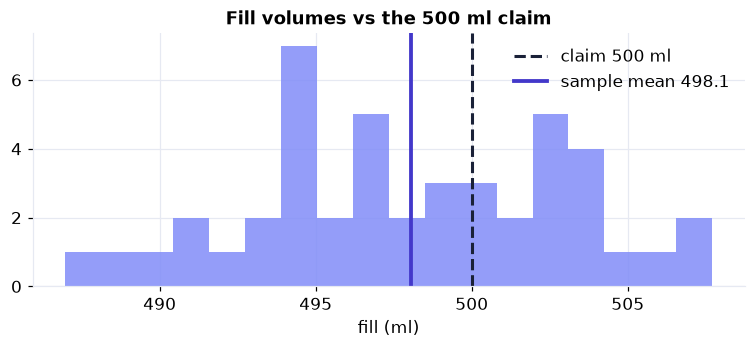

In [6]:
lo,hi = stats.t.interval(0.95, n-1, xbar, se)
d = (xbar-mu0)/s
print(f"95% CI for the true mean fill: [{lo:.2f}, {hi:.2f}] ml  (500 sits at/above the upper edge)")
print(f"effect size Cohen\u2019s d = {d:.2f}  (a small-to-moderate shortfall)")
fig,ax=plt.subplots(figsize=(7,3.3))
ax.hist(x, bins=18, color=LIGHT, alpha=0.85)
ax.axvline(mu0, color=INK, lw=2, ls="--", label="claim 500 ml")
ax.axvline(xbar, color=DEEP, lw=2.5, label=f"sample mean {xbar:.1f}")
ax.set_title("Fill volumes vs the 500 ml claim"); ax.set_xlabel("fill (ml)"); ax.legend()
plt.tight_layout(); plt.show()

The sample averages about <strong>498.1 ml</strong> with t = -2.57 and a one-sided p-value of roughly <strong>0.007</strong>, well below 0.05, so we reject the 500 ml claim: the shortfall is real, not noise. Note the two faces of the same evidence, the 95% interval [496.6, 499.6] sits below 500, agreeing with the test. The effect is modest (d &#8776; -0.38), which is exactly why we needed a test rather than eyeballing the average.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ The logic of testing</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Every hypothesis test runs the same four steps: state H0 (no effect) and H1 (the claim), pick a test statistic, find its sampling distribution UNDER H0, then compute a p-value and compare it to alpha. Small p means the data would be surprising if H0 were true, evidence to reject it. On real fill data, t = -2.57, one-sided p &#8776; 0.007: the bottles really are under-filled. Chapter 75 sharpens what the p-value and alpha do and do not promise.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>